### **Load libraries**

In [21]:
import sys
sys.path.append('../src')
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import risk_kit as rk
import importlib

In [22]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
pd.options.display.max_rows = 100
pd.options.display.max_columns = 100

### **Load data**

In [24]:
rets = pd.read_csv('../temp_references/selected_stocks_rets.csv', index_col=0)
stocks = pd.read_csv('../temp_references/selected_stocks_stocks.csv', index_col=0)

In [25]:
expected_returns = pd.read_csv('../temp_references/expected_returns.csv', index_col=0, header=None).iloc[:,0]
expected_covmat = pd.read_csv('../temp_references/expected_covmat.csv', index_col=0)

In [26]:
# Define the number of periods per year for all calculations
# 252 is an approximation for daily
# 54 for weekly
# 12 for monthly
periods_per_year = 54

# **Initial examination**

In [27]:
summary_stats = rk.summary_stats(rets, periods_per_year=periods_per_year, riskfree_rate=0)
summary_stats

,Annualized Return,Annualized Volatility,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
BOGOTA.CL,0.019926,0.284626,-0.804036,12.131830,0.063816,0.100391,0.070006,-0.633000
BVC.CL,0.144713,0.259348,0.736224,7.036828,0.044313,0.070308,0.557988,-0.356135
CELSIA.CL,0.137277,0.280128,2.583187,25.283283,0.009718,0.072082,0.490051,-0.476794
CIBEST.CL,0.209863,0.359164,0.240363,15.021404,0.060409,0.097414,0.584310,-0.581655
CNEC.CL,-0.171876,0.385216,3.030476,36.960241,-0.001696,0.103409,-0.446182,-0.923684
CONCONCRET.CL,-0.074221,1.087878,15.764242,323.453308,-2.072873,0.140517,-0.068226,-0.864859
ECOPETROL.CL,0.188642,0.387804,-0.269223,9.424594,0.079305,0.112885,0.486436,-0.598050
ENKA.CL,0.058804,0.395682,1.943917,14.388014,0.040189,0.099697,0.148614,-0.562287
ETB.CL,-0.227059,0.345858,0.757810,9.720676,0.064049,0.113508,-0.656509,-0.928790
EXITO.CL,0.025213,0.345126,1.036455,12.560000,0.051866,0.101779,0.073056,-0.659980


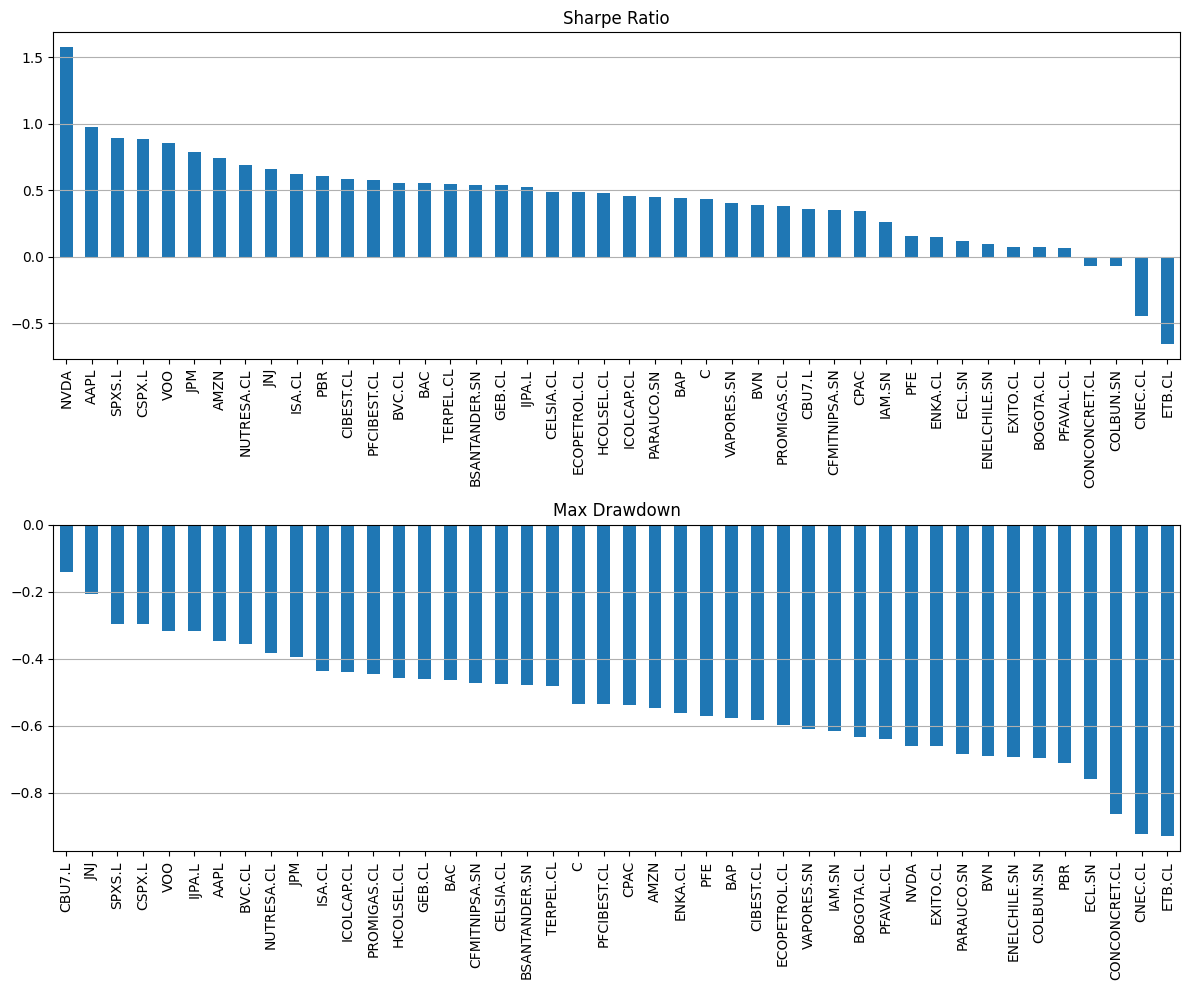

In [28]:
# Plot some return, volatility, and risk rankings to get a view of relevant stocks
summary_stats = rk.summary_stats(rets, periods_per_year=periods_per_year)
#plot1_series = summary_stats['Annualized Return'].sort_values(ascending=False)
#plot2_series = summary_stats['Annualized Volatility'].sort_values(ascending=True)
#plot1_series = summary_stats['Cornish-Fisher VaR (5%)'].sort_values(ascending=False)
#plot2_series = summary_stats['Historic CVaR (5%)'].sort_values(ascending=False)
plot1_series = summary_stats['Sharpe Ratio'].sort_values(ascending=False)
plot2_series = summary_stats['Max Drawdown'].sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))
plot1_series.plot.bar(ax = axes[0], legend=False, title=plot1_series.name)
plot2_series.plot.bar(ax=axes[1], legend=False, title=plot2_series.name)
axes[0].grid(axis='y')
axes[1].grid(axis='y')
plt.tight_layout()

In [29]:
# Identify stock pairs with very high correlation

# Generate correlation matrix
corr_mat = rets.corr()
# Generate a mask to exclude  duplicated pairs
#mask = np.triu(np.ones_like(corr_mat))
#corr_mat = corr_mat*mask
# Convert the matrix into a dataframe structured as a list of pairs with their respective correlations
stack_corr = pd.DataFrame(corr_mat.stack())
stack_corr = stack_corr[stack_corr[0] < 1]
stack_corr = stack_corr[stack_corr[0] != 0]
stack_corr.index.names = ['Stock 1', 'Stock 2']
stack_corr.reset_index(inplace=True)
#(abs(stack_corr[0]) > .7).sum()

# Filter to visualize only the pairs with very high correlations
high_corrs = stack_corr[stack_corr[0] >= 0.8].sort_values(by=0, ascending=False)
high_corrs

,Stock 1,Stock 2,0
1330,CSPX.L,SPXS.L,0.998523
1793,SPXS.L,CSPX.L,0.998523
1332,CSPX.L,VOO,0.922762
1879,VOO,CSPX.L,0.922762
1805,SPXS.L,VOO,0.921610
1890,VOO,SPXS.L,0.921610
938,BAC,JPM,0.895572
1569,JPM,BAC,0.895572
927,BAC,C,0.865091
1096,C,BAC,0.865091


In [30]:
# Check the average correlation coefficient of each stock
stack_corr.groupby('Stock 1')[0].mean().sort_values(ascending=False)

Stock 1
VOO              0.332811
SPXS.L           0.328043
CSPX.L           0.327509
ICOLCAP.CL       0.323887
CFMITNIPSA.SN    0.293923
C                0.290681
HCOLSEL.CL       0.285622
PFCIBEST.CL      0.271544
JPM              0.261063
CIBEST.CL        0.258757
BAC              0.258274
IJPA.L           0.253504
PFAVAL.CL        0.247821
ECOPETROL.CL     0.236219
BAP              0.222559
PARAUCO.SN       0.220032
PBR              0.206823
ISA.CL           0.201014
BSANTANDER.SN    0.192431
AAPL             0.191989
BOGOTA.CL        0.176417
ENELCHILE.SN     0.175995
VAPORES.SN       0.174712
NVDA             0.167806
JNJ              0.165107
AMZN             0.165076
CELSIA.CL        0.160183
PFE              0.153918
IAM.SN           0.141412
ECL.SN           0.136558
GEB.CL           0.131957
ETB.CL           0.122165
COLBUN.SN        0.121991
TERPEL.CL        0.118647
BVC.CL           0.105358
BVN              0.103433
EXITO.CL         0.103257
PROMIGAS.CL      0.082883
CNEC

# **Identify Combination with the maximum Sharpe-Ratio**

In [31]:
# Based on historical returns
n_periods = 162
# returns = rk.summary_stats(rets.iloc[-n_periods:], periods_per_year=periods_per_year)['Annualized Return']
# covmat = rets.iloc[-n_periods:].cov()

# Based on predicted returns
returns = expected_returns
covmat = expected_covmat

In [32]:
# Loop that calculates the combination that maximizes the Sharpe ratio several times until no stock has less than 5% of weight
rf_rate = .11   # Currently, the 10-Y  bond yield is at 11.2%
max_weight = 0.15 # The maximum weight allowed for a stock
min_weight = .05 # The minimum weight allowed for a stock
initial_weights = rk.msr_tuned(riskfree_rate=rf_rate,
                         returns=returns,
                         covmat=covmat,
                         max_weight=max_weight,
                         periods_per_year=periods_per_year)
optimal_allocation = pd.DataFrame(data=initial_weights, index=returns.index, columns=['Weights']).sort_values(by='Weights')

while optimal_allocation.min().values < min_weight:
    optimal_allocation = optimal_allocation[1:]
    weights = rk.msr_tuned(riskfree_rate=rf_rate,
                     returns=returns[optimal_allocation.index],
                     covmat=covmat.loc[optimal_allocation.index, optimal_allocation.index],
                     max_weight=max_weight,
                     periods_per_year=periods_per_year)
    optimal_allocation = pd.DataFrame(data=weights, index=optimal_allocation.index, columns=['Weights']).sort_values(by='Weights')

chosen_allocation = optimal_allocation
chosen_allocation

C:\Python projects\Finance\lib\site-packages\scipy\optimize\_slsqp_py.py:437: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)


,Weights
0,
BOGOTA.CL,0.077263
ENELCHILE.SN,0.096995
PFCIBEST.CL,0.111724
NVDA,0.114334
PBR,0.149684
BVC.CL,0.150000
COLBUN.SN,0.150000
VOO,0.150000


In [33]:
"""
# Alternative methodology finding the combination that maximizes the Sharpe ratio and then removing any stock with a weight below 5%
rf_rate = .11   # Currently, the 10-Y  bond yield is at 11.2%

weights = rk.msr(riskfree_rate=rf_rate, return_series=rets, periods_per_year=periods_per_year)
optimal_allocation = pd.DataFrame(data=weights.round(4), index=rets.columns, columns=['Weights'])
optimal_allocation = optimal_allocation[optimal_allocation['Weights'] >= .05]

# Reduce the portfolio stocks to only those for which shares of over 3% is recommended
chosen_allocation = optimal_allocation[optimal_allocation['Weights'] > .05]
chosen_allocation = chosen_allocation / chosen_allocation.sum()
chosen_allocation.sort_values(by='Weights')
"""

"\n# Alternative methodology finding the combination that maximizes the Sharpe ratio and then removing any stock with a weight below 5%\nrf_rate = .11   # Currently, the 10-Y  bond yield is at 11.2%\n\nweights = rk.msr(riskfree_rate=rf_rate, return_series=rets, periods_per_year=periods_per_year)\noptimal_allocation = pd.DataFrame(data=weights.round(4), index=rets.columns, columns=['Weights'])\noptimal_allocation = optimal_allocation[optimal_allocation['Weights'] >= .05]\n\n# Reduce the portfolio stocks to only those for which shares of over 3% is recommended\nchosen_allocation = optimal_allocation[optimal_allocation['Weights'] > .05]\nchosen_allocation = chosen_allocation / chosen_allocation.sum()\nchosen_allocation.sort_values(by='Weights')\n"

<Axes: xlabel='Date'>

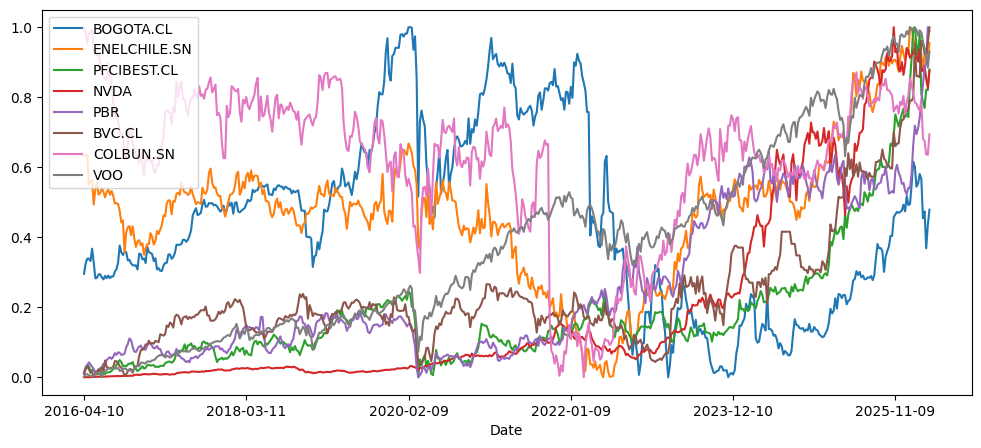

In [34]:
normalized_stocks = (stocks - stocks.min()) / (stocks.max() - stocks.min())
normalized_stocks[optimal_allocation.index].plot(figsize=(12, 5))

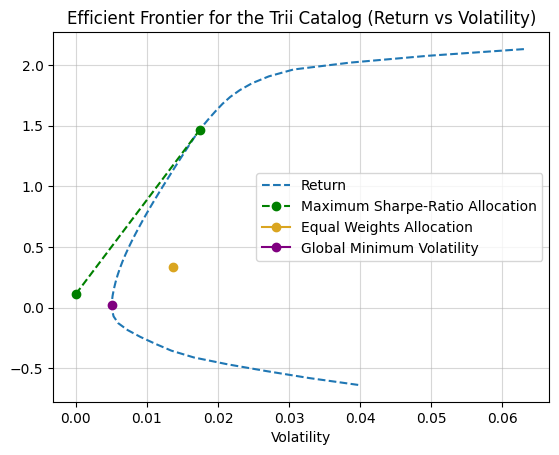

In [35]:
rk.plot_ef(50, style='--', show_cml=True, show_ew=True, show_gmv=True, riskfree_rate=rf_rate,
           returns=returns, covmat=covmat, periods_per_year=periods_per_year)
plt.title('Efficient Frontier for the Trii Catalog (Return vs Volatility)')
plt.grid(alpha=.5)

# **Create an index for the chosen allocation**

In [36]:
# Generate a dataframe to represent the evolution of the allocation in each stock
weights = chosen_allocation['Weights']
allocated_index = (rets[weights.index] + 1).cumprod()*weights

# Add a column to represent the index
allocated_index['index'] = allocated_index.sum(axis='columns')
allocated_index.index = pd.to_datetime(allocated_index.index.str.split('/').str[0])

# Generate a row to represent an earlier period before returns are made,
# corresponding to the time when the index equal 1
first_period = allocated_index.index[0]
starting_period = first_period - pd.offsets.Week(weekday=6)   # Uncomment to generate a week starting period
#starting_period = first_period - pd.offsets.DateOffset(months=1)   # Uncomment to generate a month starting period
starting_period

allocation_start = pd.DataFrame(index=[starting_period], columns=allocated_index.columns)
allocation_start.iloc[:, :-1] = 1*weights
allocation_start['index'] = 1

# Append the row to the allocated_index dataframe
allocated_index = pd.concat([allocation_start, allocated_index], axis='rows')
allocated_index.head()

,BOGOTA.CL,ENELCHILE.SN,PFCIBEST.CL,NVDA,PBR,BVC.CL,COLBUN.SN,VOO,index
2016-04-10,0.077263,0.096995,0.111724,0.114334,0.149684,0.15,0.15,0.15,1.000000
2016-04-17,0.079838,0.096995,0.120478,0.119047,0.174935,0.155085,0.148562,0.152391,1.047331
2016-04-24,0.0811,0.096995,0.123511,0.11629,0.187431,0.158475,0.145086,0.153271,1.062159
2016-05-01,0.081126,0.088188,0.122125,0.113917,0.200707,0.155085,0.148029,0.15132,1.060497
2016-05-08,0.080519,0.089267,0.112764,0.113276,0.190815,0.151695,0.148445,0.150864,1.037644


In [37]:
# Generate a dataframe with the returns of the index
allocated_index_returns = (allocated_index/allocated_index.shift(1) - 1).dropna()
allocated_index_returns.tail()

,BOGOTA.CL,ENELCHILE.SN,PFCIBEST.CL,NVDA,PBR,BVC.CL,COLBUN.SN,VOO,index
2026-03-08,-0.09807,-0.040383,-0.021063,0.003555,0.058328,-0.005882,-0.088407,-0.019983,0.004337
2026-03-15,0.018767,0.041369,-0.018304,0.013666,0.055114,-0.022485,-0.006491,-0.015103,0.014174
2026-03-22,-0.1,0.013699,0.05332,-0.041834,0.012386,0.0,-0.034488,-0.018306,-0.035461
2026-03-29,0.070175,-0.028514,-0.001553,-0.029994,0.104787,0.024213,-0.000787,-0.025053,-0.019286
2026-04-05,0.043049,0.042009,0.057437,0.058918,-0.010111,0.034279,0.055039,0.037624,0.052857


In [38]:
summary_stats = rk.summary_stats(allocated_index_returns, periods_per_year=periods_per_year, riskfree_rate=0)
summary_stats

,Annualized Return,Annualized Volatility,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%),Sharpe Ratio,Max Drawdown
BOGOTA.CL,0.019926,0.284626,-0.804036,12.131830,0.063816,0.100391,0.070006,-0.633000
ENELCHILE.SN,0.031145,0.321410,0.281154,6.002583,0.064212,0.096803,0.096900,-0.691931
PFCIBEST.CL,0.178720,0.310850,-0.175037,9.849369,0.061859,0.089149,0.574939,-0.536017
NVDA,0.734643,0.466096,0.359878,4.526729,0.083508,0.116430,1.576163,-0.659360
PBR,0.294703,0.486982,-0.173793,6.273022,0.100840,0.137473,0.605161,-0.710030
BVC.CL,0.144713,0.259348,0.736224,7.036828,0.044313,0.070308,0.557988,-0.356135
COLBUN.SN,-0.024561,0.344040,-1.024475,22.995388,0.070119,0.094113,-0.071389,-0.696125
VOO,0.148408,0.173690,-0.566171,9.114783,0.036775,0.054751,0.854440,-0.317619
index,0.407485,0.312908,0.119521,5.132193,0.059499,0.087667,1.302254,-0.468434


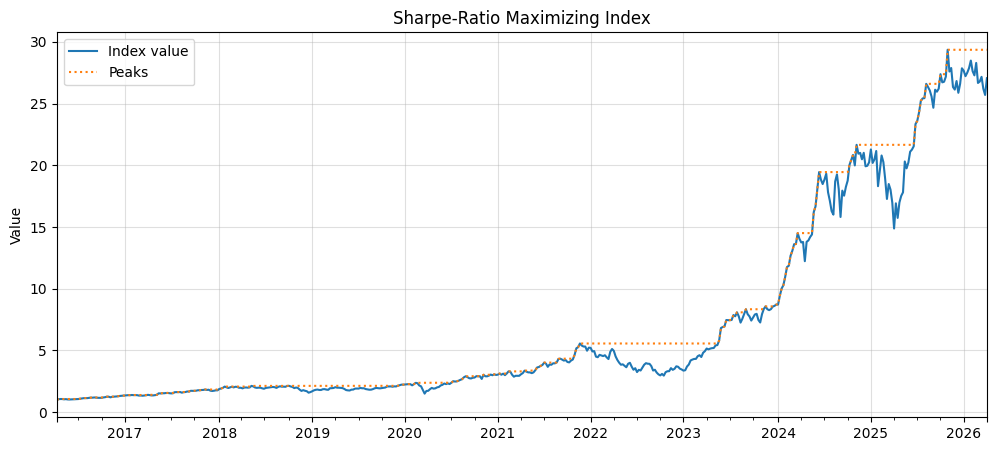

In [39]:
# Visualize the evolution of the index
allocated_index['index'].plot(figsize=(12, 5), label='Index value')
allocated_index['index'].cummax().plot(linestyle=':', label='Peaks')
plt.legend()
plt.ylabel('Value')
plt.title('Sharpe-Ratio Maximizing Index')
plt.grid(alpha=0.4)

### **Export datasets and an index for the Sharpe-Ratio maximizing allocation**

In [40]:
# Allocation index and returns
allocated_index.to_csv('../temp_references/allocated_index.csv')
allocated_index_returns.to_csv('../temp_references/allocated_index_returns.csv')